# Week 05 — Hidden Layer Lab

Goal: compare a straight-line classifier with a small neural network on the same curved dataset.

The main question:

Can a model with one straight recipe solve a curved two-class problem, or do we need learned intermediate features?

In [35]:
from pathlib import Path



def find_project_root(start: Path) -> Path:
   for candidate in [start, *start.parents]:
       if (candidate / "pyproject.toml").exists():
           return candidate
   raise FileNotFoundError("Could not find project root containing pyproject.toml.")

project_root = find_project_root(Path.cwd()).resolve()

In [36]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
LEARNING_RATE = 0.01

## Generate the moon-shaped dataset

Each row has two input features:

- `x_position`
- `y_position`

The answer column is:

- `class_label`

Expected shape: `(500, 3)` because there are 500 rows and 3 columns.

In [37]:
import pandas as pd
from sklearn.datasets import make_moons

data_path = project_root / "data" / "generated" / "week-05-moons.csv"
data_path.parent.mkdir(parents=True, exist_ok=True)

X, y = make_moons(
    n_samples=500,
    noise=0.25,
    random_state=RANDOM_STATE,
)

points = pd.DataFrame(
    {
        "x_position": X[:, 0],
        "y_position": X[:, 1],
        "class_label": y,
    }
)

points.to_csv(data_path, index=False)

print(points.shape)
points.head()

(500, 3)


,x_position,y_position,class_label
0,0.830948,-0.296546,1
1,1.088387,0.899693,0
2,1.135634,-0.462935,1
3,-0.082277,1.059718,0
4,0.443047,1.418977,0


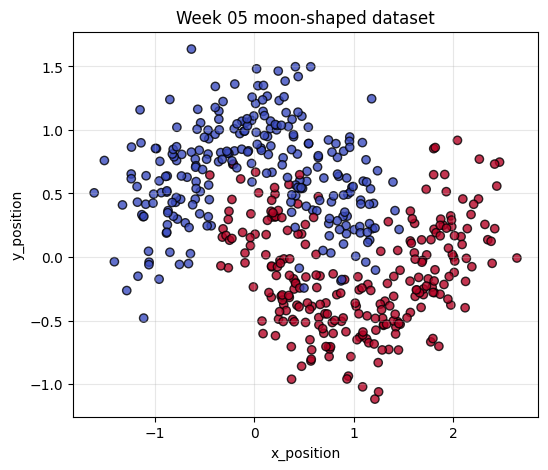

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

scatter = ax.scatter(
    points["x_position"],
    points["y_position"],
    c=points["class_label"],
    cmap="coolwarm",
    edgecolor="black",
    alpha=0.8
)

ax.set_title("Week 05 moon-shaped dataset")
ax.set_xlabel("x_position")
ax.set_ylabel("y_position")
ax.grid(True, alpha=0.3)

plt.show()


## Raw data observation

The two classes form curved moon shapes.

A single straight line may classify many points correctly, but it probably cannot cleanly separate the two curves.

In [39]:
from sklearn.model_selection import train_test_split

features = points[["x_position", "y_position"]].to_numpy()
labels = points["class_label"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=labels,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (400, 2)
X_test: (100, 2)
y_train: (400,)
y_test: (100,)


## Convert arrays to tensors

`X_train` is a matrix of input positions with shape `(400, 2)`.

`y_train` is one class label per row. We reshape it to `(400, 1)` so it matches the model output shape.

In [40]:
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

print("X_train_tensor:", X_train_tensor.shape, X_train_tensor.dtype)
print("y_train_tensor:", y_train_tensor.shape, y_train_tensor.dtype)
print("X_test_tensor:", X_test_tensor.shape, X_test_tensor.dtype)
print("y_test_tensor:", y_test_tensor.shape, y_test_tensor.dtype)

X_train_tensor: torch.Size([400, 2]) torch.float32
y_train_tensor: torch.Size([400, 1]) torch.float32
X_test_tensor: torch.Size([100, 2]) torch.float32
y_test_tensor: torch.Size([100, 1]) torch.float32


In [41]:
import torch.nn as nn

torch.manual_seed(RANDOM_STATE)

linear_model = nn.Linear(in_features=2, out_features=1)

for name, parameter in linear_model.named_parameters():
    print(name, parameter.shape)
    
with torch.no_grad():
    sample_logits = linear_model(X_train_tensor[:5])

print(f"sample_logits shape: {sample_logits.shape}")
sample_logits

weight torch.Size([1, 2])
bias torch.Size([1])
sample_logits shape: torch.Size([5, 1])


tensor([[ 0.3178],
        [ 0.6995],
        [-0.3307],
        [-0.4307],
        [ 0.1584]])

## Logits and sigmoid

The linear model outputs logits.

A logit is a raw score. Sigmoid turns each logit into a probability between `0` and `1`.

Positive logits become probabilities above `0.5`; negative logits become probabilities below `0.5`.

In [42]:
torch.sigmoid(sample_logits)

tensor([[0.5788],
        [0.6681],
        [0.4181],
        [0.3940],
        [0.5395]])

## Train the linear baseline

The linear model can only learn one direct recipe:

`score = weight_1 * x_position + weight_2 * y_position + bias`

Because the moons are curved, this model may improve for many epochs but still hit a shape limit.

In [43]:
loss_function = nn.BCEWithLogitsLoss()

linear_optimizer = torch.optim.SGD(linear_model.parameters(), lr=LEARNING_RATE)

linear_losses: list[float] = []

for epoch in range(2000):
    linear_model.train()
    
    logits = linear_model(X_train_tensor)
    loss = loss_function(logits, y_train_tensor)
    
    linear_optimizer.zero_grad()
    loss.backward()
    linear_optimizer.step()
    
    linear_losses.append(float(loss.item()))
    
    if epoch % 200 == 0:
        print(f"epoch {epoch}, loss {loss.item():.4f}")
        
print(f"Final linear loss: {linear_losses[-1]:.4f}")

epoch 0, loss 0.7132
epoch 200, loss 0.5880
epoch 400, loss 0.5150
epoch 600, loss 0.4691
epoch 800, loss 0.4380
epoch 1000, loss 0.4157
epoch 1200, loss 0.3990
epoch 1400, loss 0.3860
epoch 1600, loss 0.3756
epoch 1800, loss 0.3670
Final linear loss: 0.3599


In [44]:
def binary_accuracy_from_logits(logits: torch.Tensor, labels: torch.Tensor) -> float:
       probabilities = torch.sigmoid(logits)
       predictions = (probabilities >= 0.5).float()
       accuracy = (predictions == labels).float().mean()
       return float(accuracy.item())


linear_model.eval()

with torch.no_grad():
    train_logits = linear_model(X_train_tensor)
    test_logits = linear_model(X_test_tensor)

    linear_train_accuracy = binary_accuracy_from_logits(train_logits, y_train_tensor)
    linear_test_accuracy = binary_accuracy_from_logits(test_logits, y_test_tensor)
    linear_final_loss = loss_function(train_logits, y_train_tensor)

print(f"linear train accuracy: {linear_train_accuracy:.3f}")
print(f"linear test accuracy: {linear_test_accuracy:.3f}")
print(f"linear final train loss: {linear_final_loss.item():.4f}")

linear train accuracy: 0.825
linear test accuracy: 0.810
linear final train loss: 0.3599


## Linear baseline findings

The linear model reached:

- train accuracy: `0.848`
- test accuracy: `0.820`
- final train loss: `0.3238`

Because both train and test accuracy are limited, this looks more like a model-capacity limit than overfitting.

Next we need to train an MLP with one hidden layer and compare whether extra learned features help bend the decision boundary.

In [45]:
HIDDEN_UNITS = 16

torch.manual_seed(RANDOM_STATE)

mlp_model = nn.Sequential(
    nn.Linear(in_features=2, out_features=HIDDEN_UNITS),
    nn.ReLU(),
    nn.Linear(in_features=HIDDEN_UNITS, out_features=1)
)

for name, parameter in mlp_model.named_parameters():
    print(name, parameter.shape)
    
with torch.no_grad():
    sample_mlp_logits = mlp_model(X_train_tensor[:5])
    
print(f"sample_mlp_logits shape: {sample_mlp_logits.shape}")
print(sample_mlp_logits)

0.weight torch.Size([16, 2])
0.bias torch.Size([16])
2.weight torch.Size([1, 16])
2.bias torch.Size([1])
sample_mlp_logits shape: torch.Size([5, 1])
tensor([[ 0.3598],
        [ 0.4573],
        [-0.1526],
        [-0.0877],
        [ 0.3141]])


## MLP as a chain of functions

The neural-network language is a metaphor.

In code, this model is a chain of functions:

`logit = linear_2(relu(linear_1(input_point)))`

The first linear function maps each 2-number point into 16 learned intermediate numbers.

Those 16 numbers are called hidden units, but they are not literal neurons. A more concrete name is:

**16 learned intermediate features**

The first layer has shape `[16, 2]` because it creates 16 outputs, and each output uses both input features:

- `x_position`
- `y_position`

So the first layer has:

- `16 * 2 = 32` weights
- `16` biases

Each hidden output follows this pattern:

`hidden_raw_i = weight_ix * x_position + weight_iy * y_position + bias_i`

Then `ReLU` changes negative hidden values to `0`.

`ReLU` does not appear in `named_parameters()` because it has no learned parameters. It is still layer index `1` inside `nn.Sequential`.

### Connection-first Pyplot diagram

This diagram shows the model as values connected by weighted operations.

The circles are values:

- 2 input values
- 16 intermediate hidden values
- 1 output logit

The lines are weighted operations.

Each line represents both:

- a stored learned weight
- the multiplication that uses it, such as `weight_ix * x_position`

A full hidden output also adds its bias:

`hidden_raw_i = weight_ix * x_position + weight_iy * y_position + bias_i`

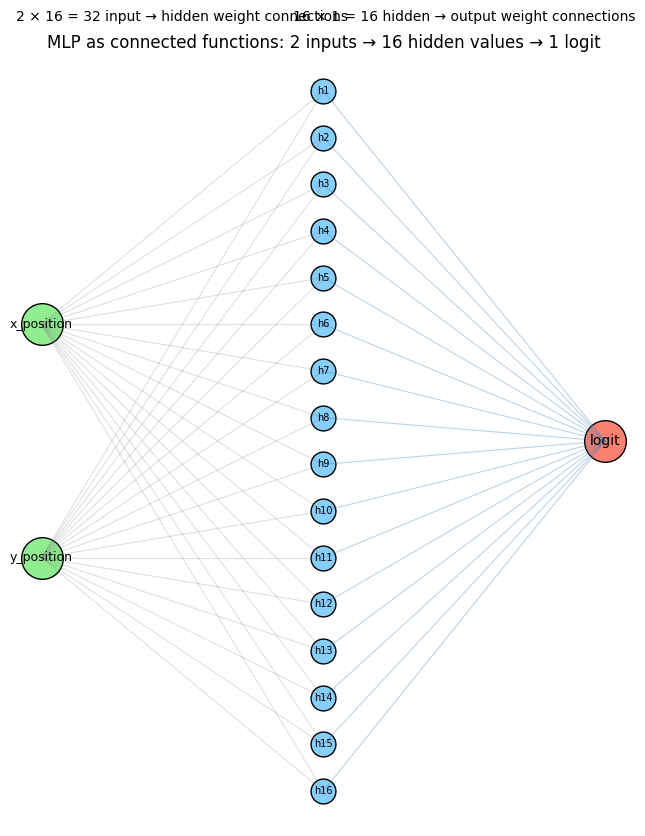

saved connection diagram to: C:\Users\giloz\dev\intuitive_understanding_machine_learning\artifacts\week-05-small-neural-networks\mlp_connections.png


In [46]:
from matplotlib.axes import Axes
from matplotlib.figure import Figure

connection_plot_path = (
    project_root
    / "artifacts"
    / "week-05-small-neural-networks"
    / "mlp_connections.png"
)
connection_plot_path.parent.mkdir(parents=True, exist_ok=True)

figure: Figure
axis: Axes
figure, axis = plt.subplots(figsize=(8, 10))

input_nodes: list[tuple[str, float, float]] = [
    ("x_position", 0.0, 0.65),
    ("y_position", 0.0, 0.35),
]

hidden_y_positions: list[float] = [
    0.95 - index * (0.90 / (HIDDEN_UNITS - 1))
    for index in range(HIDDEN_UNITS)
]

hidden_nodes: list[tuple[str, float, float]] = [
    (f"h{index + 1}", 1.0, y_position)
    for index, y_position in enumerate(hidden_y_positions)
]

output_node: tuple[str, float, float] = ("logit", 2.0, 0.5)

for _, input_x, input_y in input_nodes:
    for _, hidden_x, hidden_y in hidden_nodes:
        axis.plot(
            [input_x, hidden_x],
            [input_y, hidden_y],
            color="gray",
            alpha=0.25,
            linewidth=0.8,
        )

for _, hidden_x, hidden_y in hidden_nodes:
    axis.plot(
        [hidden_x, output_node[1]],
        [hidden_y, output_node[2]],
        color="steelblue",
        alpha=0.35,
        linewidth=0.8,
    )

for label, x_position, y_position in input_nodes:
    axis.scatter(x_position, y_position, s=900, color="lightgreen", edgecolor="black")
    axis.text(x_position, y_position, label, ha="center", va="center", fontsize=9)

for label, x_position, y_position in hidden_nodes:
    axis.scatter(x_position, y_position, s=320, color="lightskyblue", edgecolor="black")
    axis.text(x_position, y_position, label, ha="center", va="center", fontsize=7)

axis.scatter(output_node[1], output_node[2], s=900, color="salmon", edgecolor="black")
axis.text(output_node[1], output_node[2], output_node[0], ha="center", va="center", fontsize=10)

axis.text(0.5, 1.04, "2 × 16 = 32 input → hidden weighted operations", ha="center")
axis.text(1.5, 1.04, "16 × 1 = 16 hidden → output weighted operations", ha="center")
axis.set_title("MLP as weighted operations: 2 inputs → 16 hidden values → 1 logit")
axis.axis("off")

figure.savefig(connection_plot_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"saved connection diagram to: {connection_plot_path}")

In [47]:
mlp_model

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
)

## Sequential layer numbering

`nn.Sequential` numbers every layer in order:

- layer `0`: first `Linear`
- layer `1`: `ReLU`
- layer `2`: second `Linear`

`named_parameters()` skips layer `1` because `ReLU` has no weights or biases to train.

That is why the printed parameter names jump from `0.bias` to `2.weight`.

In [48]:
first_layer = mlp_model[0]
relu_layer = mlp_model[1]

with torch.no_grad():
    hidden_raw = first_layer(X_train_tensor[:5])
    hidden_after_relu = relu_layer(hidden_raw)

print("input shape:", X_train_tensor[:5].shape)
print("hidden raw shape:", hidden_raw.shape)
print("hidden after ReLU shape:", hidden_after_relu.shape)
print(hidden_after_relu)

input shape: torch.Size([5, 2])
hidden raw shape: torch.Size([5, 16])
hidden after ReLU shape: torch.Size([5, 16])
tensor([[1.0293, 0.0000, 0.0000, 0.0000, 1.2998, 1.4038, 0.7938, 0.3305, 0.9351,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.8755, 1.3819],
        [1.4111, 0.0000, 0.0000, 0.0000, 1.1282, 1.5641, 0.9214, 0.3307, 1.0707,
         0.0000, 0.0000, 0.1583, 0.0000, 0.0000, 0.5282, 1.1706],
        [0.3808, 0.6643, 0.0037, 1.0140, 0.0000, 0.0637, 0.0000, 0.0000, 0.0000,
         0.2312, 0.5590, 1.1861, 0.7466, 0.0000, 0.0000, 0.0000],
        [0.2809, 0.4878, 0.0000, 0.8806, 0.0000, 0.0837, 0.0000, 0.0000, 0.0000,
         0.1577, 0.5516, 1.0441, 0.7799, 0.0000, 0.1069, 0.0000],
        [0.8700, 0.0000, 0.0000, 0.0000, 1.1717, 1.2475, 0.6617, 0.2518, 0.7971,
         0.0000, 0.0000, 0.0099, 0.0000, 0.0000, 0.8917, 1.2538]])


In [49]:
first_layer = mlp_model[0]

print("first layer weights:")
print(first_layer.weight.shape)
print(first_layer.weight)

print("first layer biases:")
print(first_layer.bias.shape)
print(first_layer.bias)

first layer weights:
torch.Size([16, 2])
Parameter containing:
tensor([[ 0.5406,  0.5869],
        [-0.1657,  0.6496],
        [-0.1549,  0.1427],
        [-0.3443,  0.4153],
        [ 0.6233, -0.5188],
        [ 0.6146,  0.1323],
        [ 0.5224,  0.0958],
        [ 0.3410, -0.0998],
        [ 0.5451,  0.1045],
        [-0.3301,  0.1802],
        [-0.3258, -0.0829],
        [-0.2872,  0.4691],
        [-0.5582, -0.3260],
        [-0.1997, -0.4252],
        [ 0.0667, -0.6984],
        [ 0.6386, -0.6007]], requires_grad=True)
first layer biases:
torch.Size([16])
Parameter containing:
tensor([ 0.5459,  0.1177, -0.2296,  0.4370,  0.1102,  0.5713,  0.0773, -0.2230,
         0.1900, -0.1918,  0.2976,  0.6313,  0.4087, -0.3091,  0.4082,  0.1265],
       requires_grad=True)


In [50]:
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=LEARNING_RATE)

mlp_losses: list[float] = []

for epoch in range(2000):
    mlp_model.train()
    
    logits  = mlp_model(X_train_tensor)
    loss = loss_function(logits, y_train_tensor)
    
    mlp_optimizer.zero_grad()
    loss.backward()
    mlp_optimizer.step()
    
    mlp_losses.append(float(loss.item()))
    
    if epoch % 200 == 0:
        print(f"epoch {epoch}, loss {loss.item():.4f}")
        
print(f"final MLP loss: {mlp_losses[-1]:.4f}")

epoch 0, loss 0.6438
epoch 200, loss 0.1645
epoch 400, loss 0.1087
epoch 600, loss 0.0997
epoch 800, loss 0.0935
epoch 1000, loss 0.0914
epoch 1200, loss 0.0903
epoch 1400, loss 0.0894
epoch 1600, loss 0.0887
epoch 1800, loss 0.0877
final MLP loss: 0.0869


In [51]:
mlp_model.eval()

with torch.no_grad():
   mlp_train_logits = mlp_model(X_train_tensor)
   mlp_test_logits = mlp_model(X_test_tensor)

   mlp_train_accuracy = binary_accuracy_from_logits(mlp_train_logits, y_train_tensor)
   mlp_test_accuracy = binary_accuracy_from_logits(mlp_test_logits, y_test_tensor)
   mlp_final_loss = loss_function(mlp_train_logits, y_train_tensor)

print(f"MLP train accuracy: {mlp_train_accuracy:.3f}")
print(f"MLP test accuracy: {mlp_test_accuracy:.3f}")
print(f"MLP final train loss: {mlp_final_loss.item():.4f}")

MLP train accuracy: 0.960
MLP test accuracy: 0.930
MLP final train loss: 0.0869


In [52]:
comparison_path = (
       project_root
       / "artifacts"
       / "week-05-small-neural-networks"
       / "model_comparison.csv"
   )
comparison_path.parent.mkdir(parents=True, exist_ok=True)

model_comparison = pd.DataFrame(
   [
       {
           "model": "linear",
           "train_accuracy": linear_train_accuracy,
           "test_accuracy": linear_test_accuracy,
           "final_loss": float(linear_final_loss.item()),
       },
       {
           "model": "mlp_16_hidden_units",
           "train_accuracy": mlp_train_accuracy,
           "test_accuracy": mlp_test_accuracy,
           "final_loss": float(mlp_final_loss.item()),
       },
   ]
)

model_comparison.to_csv(comparison_path, index=False)

print(f"saved comparison to: {comparison_path}")
model_comparison

saved comparison to: C:\Users\giloz\dev\intuitive_understanding_machine_learning\artifacts\week-05-small-neural-networks\model_comparison.csv


,model,train_accuracy,test_accuracy,final_loss
0,linear,0.825,0.81,0.359879
1,mlp_16_hidden_units,0.960,0.93,0.086871
